# Mini-Batch Gradient Descent: Full-Batch vs Mini-Batch vs Stochastic

## Learning Objectives

By the end of this notebook, you will:

1. **Understand** the three flavors of gradient descent: full-batch, mini-batch, and stochastic
2. **Master** the terminology: epochs, steps, iterations, and batches
3. **Visualize** how different batch sizes affect training dynamics
4. **Discover** why gradient noise can actually help generalization
5. **Analyze** memory and computational trade-offs of different batch sizes
6. **Build intuition** for choosing batch sizes in practice

**Philosophy**: Understanding mini-batches is foundational for all modern deep learning. This notebook builds deep intuitions through hands-on experiments and visualizations.

## Part 1: Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from aiml_notebooks import get_device, set_seed

# Set random seed for reproducibility
set_seed(42)

# Get device
device = get_device()

# Plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

print("✓ Setup complete!")

Using CPU
✓ Setup complete!


## Part 2: The Batching Problem

### What We've Learned So Far

In basic gradient descent, we update our model parameters using:

$$\theta := \theta - \eta \nabla L(\theta)$$

But there's a hidden question here: **How do we compute the loss $L(\theta)$?**

### The Dataset

Suppose we have a dataset with $n$ examples: $\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \ldots, (x^{(n)}, y^{(n)})\}$

The **total loss** is the average over all examples:

$$L(\theta) = \frac{1}{n} \sum_{i=1}^{n} \ell(f_\theta(x^{(i)}), y^{(i)})$$

### The Question

**Do we need to use ALL $n$ examples to compute the gradient?**

This leads to three different strategies:
1. **Full-Batch (Batch) Gradient Descent**: Use all $n$ examples
2. **Stochastic Gradient Descent (SGD)**: Use just 1 example at a time
3. **Mini-Batch Gradient Descent**: Use a subset of $b$ examples (where $1 < b < n$)

Let's explore each approach!

## Part 3: Creating a Synthetic Dataset

We'll use a simple 2D classification problem (like the one in the optimizers notebook) to visualize how different batching strategies work.

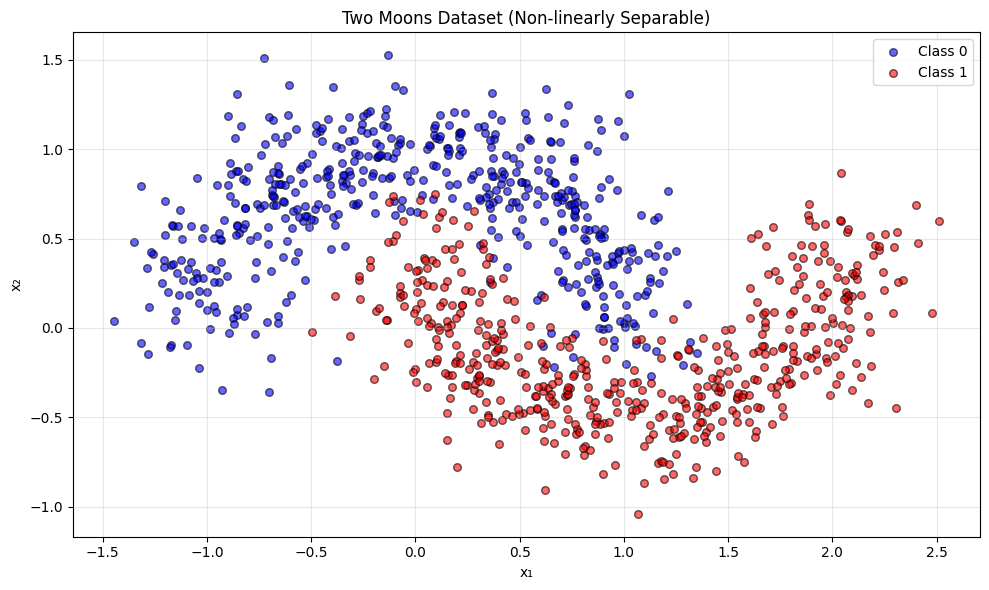

Training samples: 1000
Test samples: 200


In [2]:
def make_moons_dataset(n_samples=1000, noise=0.2):
    """
    Generate a two-class dataset with moon shapes (non-linearly separable).
    """
    np.random.seed(42)
    
    n_samples_per_class = n_samples // 2
    
    # Upper moon
    theta = np.linspace(0, np.pi, n_samples_per_class)
    X_upper = np.column_stack([
        np.cos(theta) + np.random.normal(0, noise, n_samples_per_class),
        np.sin(theta) + np.random.normal(0, noise, n_samples_per_class)
    ])
    y_upper = np.zeros(n_samples_per_class)
    
    # Lower moon
    theta = np.linspace(0, np.pi, n_samples_per_class)
    X_lower = np.column_stack([
        1 - np.cos(theta) + np.random.normal(0, noise, n_samples_per_class),
        0.5 - np.sin(theta) + np.random.normal(0, noise, n_samples_per_class)
    ])
    y_lower = np.ones(n_samples_per_class)
    
    # Combine
    X = np.vstack([X_upper, X_lower]).astype(np.float32)
    y = np.concatenate([y_upper, y_lower]).astype(np.int64)
    
    # Shuffle
    idx = np.random.permutation(n_samples)
    return X[idx], y[idx]

# Generate dataset
X_train, y_train = make_moons_dataset(n_samples=1000, noise=0.2)
X_test, y_test = make_moons_dataset(n_samples=200, noise=0.2)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
            c='blue', label='Class 0', alpha=0.6, edgecolors='k', s=30)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
            c='red', label='Class 1', alpha=0.6, edgecolors='k', s=30)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Two Moons Dataset (Non-linearly Separable)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

## Part 4: A Simple Neural Network

We'll use a small feedforward network to classify the moons. This is simple enough to train quickly but complex enough to show interesting batching effects.

In [3]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Test the model
model = SimpleClassifier().to(device)
print("✓ Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Model architecture:
SimpleClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
)

Total parameters: 354


## Part 5: Full-Batch Gradient Descent

### The Idea

**Full-Batch GD** computes the gradient using **ALL** training examples at once:

$$\nabla L(\theta) = \frac{1}{n} \sum_{i=1}^{n} \nabla \ell(f_\theta(x^{(i)}), y^{(i)})$$

### Characteristics

- ✅ **Exact gradient**: No randomness, always points toward the true minimum
- ✅ **Stable convergence**: Smooth, predictable path
- ✅ **Efficient on GPUs**: Can parallelize the computation across all examples
- ❌ **Memory intensive**: Must load entire dataset into memory
- ❌ **Slow updates**: Only one parameter update per pass through data
- ❌ **Can get stuck**: Deterministic, may settle in poor local minima

In [4]:
def train_full_batch(model, X, y, lr=0.1, num_epochs=50):
    """
    Train using full-batch gradient descent.
    
    One epoch = one pass through the entire dataset = one gradient update.
    """
    # Convert to tensors
    X_tensor = torch.from_numpy(X).to(device)
    y_tensor = torch.from_numpy(y).to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'updates': 0}
    
    for epoch in range(num_epochs):
        # Forward pass on ENTIRE dataset
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        history['loss'].append(loss.item())
        history['updates'] += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")
    
    return history

# Train with full-batch GD
print("Training with Full-Batch Gradient Descent...\n")
set_seed(42)
model_full = SimpleClassifier().to(device)
history_full = train_full_batch(model_full, X_train, y_train, lr=0.1, num_epochs=50)

print(f"\nTotal parameter updates: {history_full['updates']}")
print(f"Final loss: {history_full['loss'][-1]:.4f}")

Training with Full-Batch Gradient Descent...

Epoch 10/50, Loss: 0.6209
Epoch 20/50, Loss: 0.5385
Epoch 30/50, Loss: 0.4604
Epoch 40/50, Loss: 0.4042
Epoch 50/50, Loss: 0.3708

Total parameter updates: 50
Final loss: 0.3708


### Understanding the Output

Notice that with **full-batch** gradient descent:
- Each epoch = 1 parameter update
- 50 epochs = 50 parameter updates total
- We process all 1,000 examples at once in each update

This is **very different** from mini-batch training!

## Part 6: Stochastic Gradient Descent (SGD)

### The Idea

**Stochastic GD** is the opposite extreme: compute the gradient using **ONE** example at a time:

$$\nabla L(\theta) \approx \nabla \ell(f_\theta(x^{(i)}), y^{(i)})$$

We randomly sample one example, compute its gradient, and update immediately.

### Characteristics

- ✅ **Many updates**: $n$ updates per epoch (one per example)
- ✅ **Low memory**: Only one example in memory at a time
- ✅ **Can escape local minima**: Randomness helps exploration
- ✅ **Online learning**: Can update as new data arrives
- ❌ **Noisy gradients**: High variance, unstable path
- ❌ **Slow on GPUs**: Can't parallelize well
- ❌ **Requires small learning rate**: Otherwise oscillates too much

In [5]:
def train_stochastic(model, X, y, lr=0.01, num_epochs=50):
    """
    Train using stochastic gradient descent (batch size = 1).
    
    One epoch = n updates (one per example).
    """
    n = len(X)
    X_tensor = torch.from_numpy(X).to(device)
    y_tensor = torch.from_numpy(y).to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'updates': 0}
    
    for epoch in range(num_epochs):
        # Shuffle data each epoch
        indices = torch.randperm(n)
        
        epoch_losses = []
        
        # Process ONE example at a time
        for i in indices:
            # Get single example
            x_single = X_tensor[i:i+1]  # Keep batch dimension
            y_single = y_tensor[i:i+1]
            
            # Forward pass
            output = model(x_single)
            loss = criterion(output, y_single)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
            history['updates'] += 1
        
        # Record average loss for the epoch
        history['loss'].append(np.mean(epoch_losses))
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {history['loss'][-1]:.4f}")
    
    return history

# Train with stochastic GD
print("Training with Stochastic Gradient Descent (batch size = 1)...\n")
set_seed(42)
model_sgd = SimpleClassifier().to(device)
history_sgd = train_stochastic(model_sgd, X_train, y_train, lr=0.01, num_epochs=50)

print(f"\nTotal parameter updates: {history_sgd['updates']}")
print(f"Final loss: {history_sgd['loss'][-1]:.4f}")

Training with Stochastic Gradient Descent (batch size = 1)...



Epoch 10/50, Avg Loss: 0.1169


Epoch 20/50, Avg Loss: 0.1017


Epoch 30/50, Avg Loss: 0.0931


Epoch 40/50, Avg Loss: 0.0917


Epoch 50/50, Avg Loss: 0.0870

Total parameter updates: 50000
Final loss: 0.0870


### Key Observation

Notice the dramatic difference:
- **Full-batch**: 50 updates total (1 per epoch)
- **Stochastic**: 50,000 updates total (1,000 per epoch)

SGD makes **1,000x more parameter updates** in the same number of epochs!

## Part 7: Mini-Batch Gradient Descent

### The Best of Both Worlds

**Mini-Batch GD** is the sweet spot: use a **small subset** of $b$ examples (typically 16, 32, 64, 128, or 256):

$$\nabla L(\theta) \approx \frac{1}{b} \sum_{i \in \text{batch}} \nabla \ell(f_\theta(x^{(i)}), y^{(i)})$$

### Characteristics

- ✅ **Balanced updates**: $\lfloor n/b \rfloor$ updates per epoch
- ✅ **GPU efficient**: Batches parallelize well
- ✅ **Reasonable memory**: Moderate memory usage
- ✅ **Stable with noise**: Gradient noise helps generalization, but not too noisy
- ✅ **Fast convergence**: More updates than full-batch, less noise than SGD

This is the **standard approach** in modern deep learning!

In [6]:
def train_mini_batch(model, X, y, batch_size=32, lr=0.1, num_epochs=50):
    """
    Train using mini-batch gradient descent.
    
    One epoch = floor(n / batch_size) updates.
    """
    n = len(X)
    X_tensor = torch.from_numpy(X).to(device)
    y_tensor = torch.from_numpy(y).to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'updates': 0}
    
    for epoch in range(num_epochs):
        # Shuffle data each epoch
        indices = torch.randperm(n)
        
        epoch_losses = []
        
        # Process in mini-batches
        for i in range(0, n, batch_size):
            # Get batch indices
            batch_indices = indices[i:i+batch_size]
            
            # Get batch data
            X_batch = X_tensor[batch_indices]
            y_batch = y_tensor[batch_indices]
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
            history['updates'] += 1
        
        # Record average loss for the epoch
        history['loss'].append(np.mean(epoch_losses))
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {history['loss'][-1]:.4f}")
    
    return history

# Train with mini-batch GD
print("Training with Mini-Batch Gradient Descent (batch size = 32)...\n")
set_seed(42)
model_mini = SimpleClassifier().to(device)
history_mini = train_mini_batch(model_mini, X_train, y_train, batch_size=32, lr=0.1, num_epochs=50)

print(f"\nTotal parameter updates: {history_mini['updates']}")
print(f"Updates per epoch: {history_mini['updates'] // 50}")
print(f"Final loss: {history_mini['loss'][-1]:.4f}")

Training with Mini-Batch Gradient Descent (batch size = 32)...



Epoch 10/50, Avg Loss: 0.2769


Epoch 20/50, Avg Loss: 0.1683


Epoch 30/50, Avg Loss: 0.1050


Epoch 40/50, Avg Loss: 0.0865


Epoch 50/50, Avg Loss: 0.0872

Total parameter updates: 1600
Updates per epoch: 32
Final loss: 0.0872


## Part 8: Comparing All Three Approaches

Let's visualize how the three methods compare in terms of convergence speed and stability.

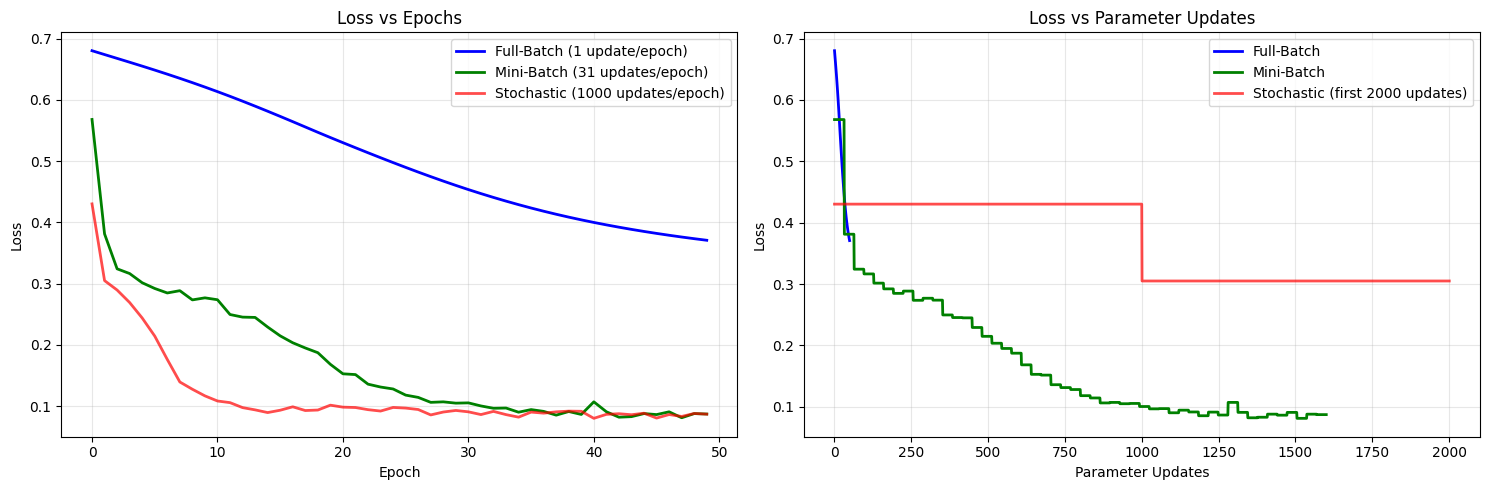

Key Observations:
  • Full-batch: Smooth but slow (few updates)
  • Mini-batch: Fast and stable (balanced)
  • Stochastic: Many updates but noisy


In [7]:
# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Loss vs Epochs
ax = axes[0]
ax.plot(history_full['loss'], label='Full-Batch (1 update/epoch)', color='blue', linewidth=2)
ax.plot(history_mini['loss'], label='Mini-Batch (31 updates/epoch)', color='green', linewidth=2)
ax.plot(history_sgd['loss'], label='Stochastic (1000 updates/epoch)', color='red', linewidth=2, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss vs Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

# Right plot: Loss vs Parameter Updates
ax = axes[1]
# For full-batch: 1 update per epoch
ax.plot(range(1, history_full['updates'] + 1), history_full['loss'],
        label='Full-Batch', color='blue', linewidth=2)

# For mini-batch: repeat each epoch's loss for its updates
steps_per_epoch_mini = history_mini['updates'] // len(history_mini['loss'])
mini_loss_per_update = []
for epoch_loss in history_mini['loss']:
    mini_loss_per_update.extend([epoch_loss] * steps_per_epoch_mini)
ax.plot(range(1, len(mini_loss_per_update) + 1), mini_loss_per_update,
        label='Mini-Batch', color='green', linewidth=2)

# For stochastic: show first 2000 updates only
steps_per_epoch_sgd = history_sgd['updates'] // len(history_sgd['loss'])
sgd_loss_per_update = []
for epoch_loss in history_sgd['loss']:
    sgd_loss_per_update.extend([epoch_loss] * steps_per_epoch_sgd)
ax.plot(range(1, min(len(sgd_loss_per_update) + 1, 2001)),
        sgd_loss_per_update[:2000],
        label='Stochastic (first 2000 updates)', color='red', linewidth=2, alpha=0.7)

ax.set_xlabel('Parameter Updates')
ax.set_ylabel('Loss')
ax.set_title('Loss vs Parameter Updates')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("  • Full-batch: Smooth but slow (few updates)")
print("  • Mini-batch: Fast and stable (balanced)")
print("  • Stochastic: Many updates but noisy")

### 🤔 Reflection Questions

1. Which method converges fastest in terms of **epochs**?
2. Which method is most **efficient** per parameter update?
3. Why is the stochastic loss curve so noisy?
4. Why might mini-batch be the best compromise?

## Part 9: Terminology - Epochs, Steps, Iterations, and Batches

These terms are often confused. Let's define them precisely:

### Core Definitions

- **Sample/Example**: One data point $(x, y)$
- **Batch**: A subset of samples processed together
- **Batch Size**: Number of samples in a batch (denoted $b$)
- **Step/Iteration**: One parameter update (one forward + backward pass on a batch)
- **Epoch**: One complete pass through the entire training dataset

### Mathematical Relationships

Given:
- $n$ = total training examples
- $b$ = batch size
- $e$ = number of epochs

Then:
$$\text{Steps per epoch} = \left\lfloor \frac{n}{b} \right\rfloor$$

$$\text{Total steps} = e \times \left\lfloor \frac{n}{b} \right\rfloor$$

### Examples

With $n = 1000$ training examples:

| Batch Size | Steps per Epoch | Steps in 50 Epochs |
|------------|-----------------|--------------------|
| 1 (SGD) | 1,000 | 50,000 |
| 32 (mini-batch) | 31 | 1,550 |
| 64 (mini-batch) | 15 | 750 |
| 1000 (full-batch) | 1 | 50 |

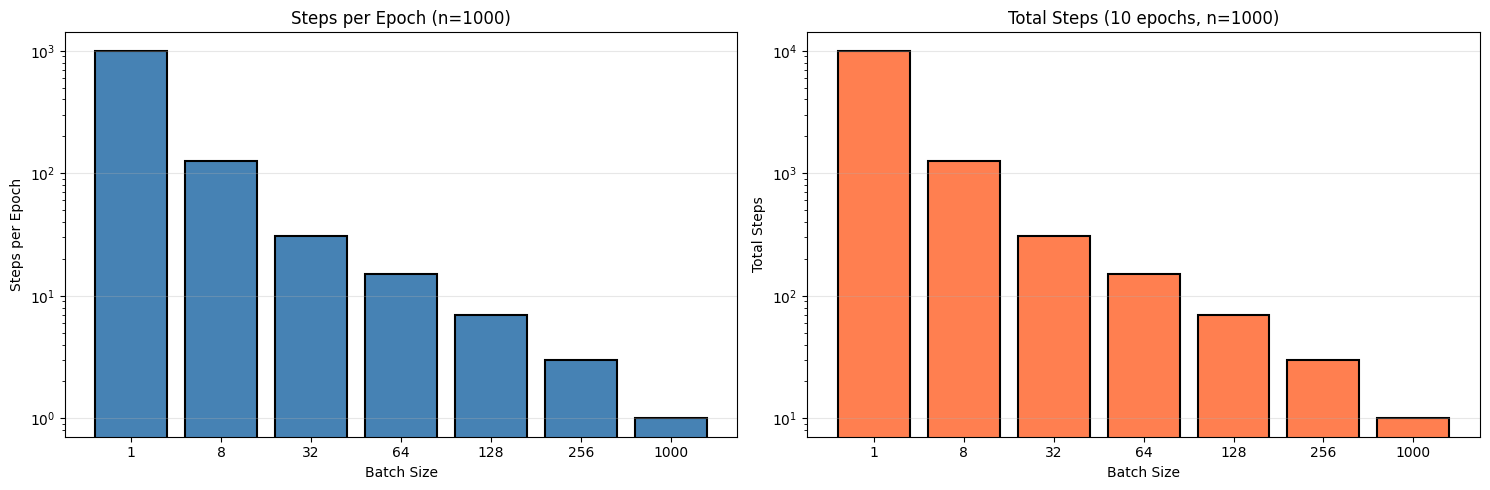


Batch Size vs Training Steps:

Batch Size   Steps/Epoch     Total Steps (10 epochs)  
----------------------------------------------------
1            1000            10000                    
8            125             1250                     
32           31              310                      
64           15              150                      
128          7               70                       
256          3               30                       
1000         1               10                       


In [8]:
# Visualize the terminology
n_samples = 1000
batch_sizes = [1, 8, 32, 64, 128, 256, 1000]
num_epochs = 10

data = []
for bs in batch_sizes:
    steps_per_epoch = n_samples // bs
    total_steps = steps_per_epoch * num_epochs
    data.append({
        'batch_size': bs,
        'steps_per_epoch': steps_per_epoch,
        'total_steps': total_steps
    })

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Steps per epoch
ax = axes[0]
ax.bar([str(d['batch_size']) for d in data], [d['steps_per_epoch'] for d in data],
       color='steelblue', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Steps per Epoch')
ax.set_title(f'Steps per Epoch (n={n_samples})')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Total steps
ax = axes[1]
ax.bar([str(d['batch_size']) for d in data], [d['total_steps'] for d in data],
       color='coral', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Total Steps')
ax.set_title(f'Total Steps ({num_epochs} epochs, n={n_samples})')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print table
print("\nBatch Size vs Training Steps:\n")
print(f"{'Batch Size':<12} {'Steps/Epoch':<15} {'Total Steps (10 epochs)':<25}")
print("-" * 52)
for d in data:
    print(f"{d['batch_size']:<12} {d['steps_per_epoch']:<15} {d['total_steps']:<25}")

### 💡 Key Insight

Smaller batches = more parameter updates per epoch = faster learning (but noisier gradients).

This is why **we can't directly compare training progress across different batch sizes using epochs alone** - we must consider the number of parameter updates!

## Part 10: Why Batching Helps - Gradient Noise

### The Surprising Truth

You might think: "More examples = better gradient = better training."

But research shows that **some gradient noise actually helps**!

### Why Noise Helps

1. **Escapes bad local minima**: Randomness helps jump out of sharp, narrow minima
2. **Finds flat minima**: Noisy gradients tend to settle in wide, flat minima (better generalization!)
3. **Regularization effect**: Acts like implicit regularization, preventing overfitting
4. **Exploration**: Randomness helps explore the loss landscape

### The Trade-off

- **Too little noise** (large batches): Converge to sharp minima, may overfit
- **Too much noise** (tiny batches): Unstable, slow convergence, wastes computation
- **Just right** (medium batches): Fast convergence + good generalization

Let's visualize this!

In [9]:
# Train with different batch sizes and compare generalization
batch_sizes_to_test = [8, 32, 128, 512]
results = {}

for bs in batch_sizes_to_test:
    print(f"\nTraining with batch size = {bs}...")
    set_seed(42)
    model = SimpleClassifier().to(device)
    
    # Adjust learning rate based on batch size (common practice)
    lr = 0.1 * (bs / 32)  # Linear scaling rule
    
    history = train_mini_batch(model, X_train, y_train, batch_size=bs, lr=lr, num_epochs=50)
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(X_test).to(device)
        y_test_tensor = torch.from_numpy(y_test).to(device)
        test_outputs = model(X_test_tensor)
        test_acc = (test_outputs.argmax(1) == y_test_tensor).float().mean().item()
    
    results[bs] = {
        'history': history,
        'test_acc': test_acc,
        'final_train_loss': history['loss'][-1]
    }
    
    print(f"  Final train loss: {history['loss'][-1]:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")


Training with batch size = 8...


Epoch 10/50, Avg Loss: 0.2709


Epoch 20/50, Avg Loss: 0.1689


Epoch 30/50, Avg Loss: 0.1023


Epoch 40/50, Avg Loss: 0.0886


...

Epoch 20/50, Avg Loss: 0.1683


Epoch 30/50, Avg Loss: 0.1050


Epoch 40/50, Avg Loss: 0.0865


Epoch 50/50, Avg Loss: 0.0872
  Final train loss: 0.0872
  Test accuracy: 0.9750

Training with batch size = 128...
Epoch 10/50, Avg Loss: 0.2846
Epoch 20/50, Avg Loss: 0.1877
Epoch 30/50, Avg Loss: 0.1051


Epoch 40/50, Avg Loss: 0.0883
Epoch 50/50, Avg Loss: 0.0798
  Final train loss: 0.0798
  Test accuracy: 0.9700

Training with batch size = 512...
Epoch 10/50, Avg Loss: 0.3167
Epoch 20/50, Avg Loss: 0.3030
Epoch 30/50, Avg Loss: 0.2636
Epoch 40/50, Avg Loss: 0.1746
Epoch 50/50, Avg Loss: 0.2436
  Final train loss: 0.2436
  Test accuracy: 0.9500


Execute the following code:

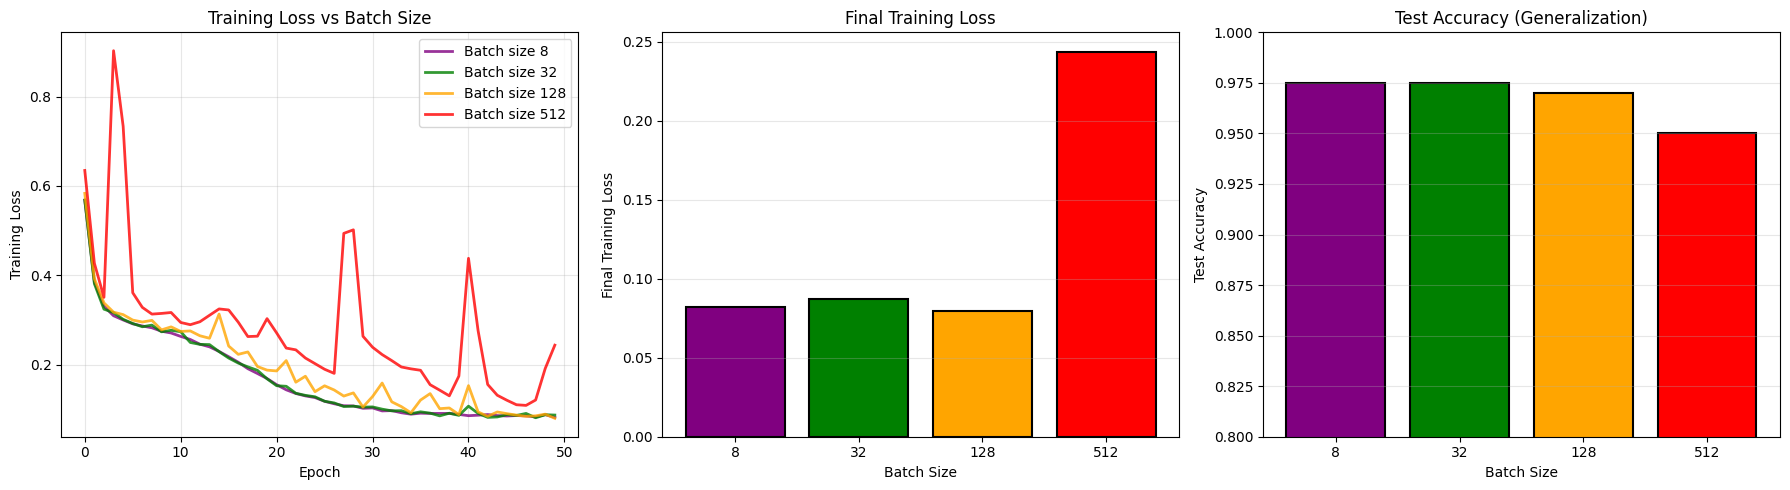


✨ Observations:
  • Smaller batches → noisier training (more oscillations)
  • Medium batches (32-128) → good balance of speed and stability
  • Very large batches → smooth but may not generalize as well


In [10]:
# Visualize batch size effects
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['purple', 'green', 'orange', 'red']

# Loss curves
ax = axes[0]
for bs, color in zip(batch_sizes_to_test, colors):
    ax.plot(results[bs]['history']['loss'], label=f'Batch size {bs}', 
            color=color, linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss vs Batch Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Final training loss
ax = axes[1]
final_losses = [results[bs]['final_train_loss'] for bs in batch_sizes_to_test]
ax.bar([str(bs) for bs in batch_sizes_to_test], final_losses, 
       color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Final Training Loss')
ax.set_title('Final Training Loss')
ax.grid(True, alpha=0.3, axis='y')

# Test accuracy
ax = axes[2]
test_accs = [results[bs]['test_acc'] for bs in batch_sizes_to_test]
ax.bar([str(bs) for bs in batch_sizes_to_test], test_accs,
       color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy (Generalization)')
ax.set_ylim([0.8, 1.0])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✨ Observations:")
print("  • Smaller batches → noisier training (more oscillations)")
print("  • Medium batches (32-128) → good balance of speed and stability")
print("  • Very large batches → smooth but may not generalize as well")

## Part 11: Memory and Computational Trade-offs

### Memory Considerations

Memory usage scales with batch size:

**Memory per batch** ≈ $b \times d \times \text{size_of_float}$

Where:
- $b$ = batch size
- $d$ = dimensions of each example

Plus memory for:
- Model parameters
- Gradients (same size as parameters)
- Optimizer state (e.g., Adam stores momentum and variance)
- Intermediate activations during forward/backward pass

### Computational Considerations

**Throughput** (examples/second):
- Small batches: Poor GPU utilization (underutilized cores)
- Large batches: Good GPU utilization (parallel processing)

**Convergence** (time to reach target loss):
- Small batches: More updates → faster convergence in steps
- Large batches: Fewer updates → slower convergence in steps, but faster per step

### The Sweet Spot

In practice, batch sizes of **32, 64, 128, or 256** work well for most problems:
- Fit in GPU memory
- Good GPU utilization
- Enough gradient noise for generalization
- Reasonable number of updates per epoch

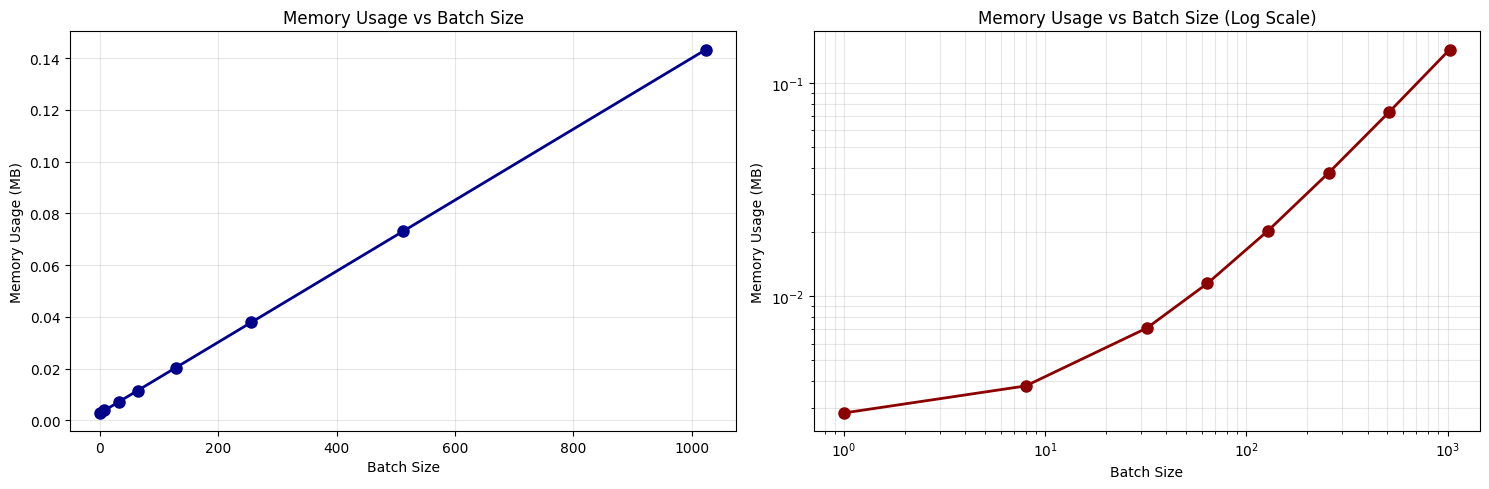

Memory Usage Estimates:

  Batch size    1: 0.0028 MB
  Batch size    8: 0.0038 MB
  Batch size   32: 0.0071 MB
  Batch size   64: 0.0115 MB
  Batch size  128: 0.0203 MB
  Batch size  256: 0.0379 MB
  Batch size  512: 0.0730 MB
  Batch size 1024: 0.1433 MB

💡 Key Insight: Memory grows linearly with batch size!
   For large models on limited GPU memory, use smaller batches.


In [11]:
# Simulate memory usage (simplified)
def estimate_memory_mb(batch_size, input_dim=2, hidden_dim=16, output_dim=2):
    """
    Rough estimate of memory usage for our simple model.
    This is illustrative - real memory usage is more complex!
    """
    bytes_per_float = 4  # 32-bit float
    
    # Activations (stored for backward pass)
    layer1_activations = batch_size * hidden_dim
    layer2_activations = batch_size * hidden_dim
    layer3_activations = batch_size * output_dim
    total_activations = (layer1_activations + layer2_activations + layer3_activations) * bytes_per_float
    
    # Input batch
    input_batch = batch_size * input_dim * bytes_per_float
    
    # Model parameters (same regardless of batch size)
    params = (input_dim * hidden_dim + hidden_dim +  # Layer 1
              hidden_dim * hidden_dim + hidden_dim +  # Layer 2
              hidden_dim * output_dim + output_dim)   # Layer 3
    params_memory = params * bytes_per_float
    
    # Gradients (same size as parameters)
    gradients_memory = params_memory
    
    total_bytes = total_activations + input_batch + params_memory + gradients_memory
    total_mb = total_bytes / (1024 * 1024)
    
    return total_mb

# Compute for different batch sizes
batch_sizes = [1, 8, 32, 64, 128, 256, 512, 1024]
memory_usage = [estimate_memory_mb(bs) for bs in batch_sizes]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear scale
ax = axes[0]
ax.plot(batch_sizes, memory_usage, 'o-', color='darkblue', linewidth=2, markersize=8)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Memory Usage (MB)')
ax.set_title('Memory Usage vs Batch Size')
ax.grid(True, alpha=0.3)

# Log scale
ax = axes[1]
ax.plot(batch_sizes, memory_usage, 'o-', color='darkred', linewidth=2, markersize=8)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Memory Usage (MB)')
ax.set_title('Memory Usage vs Batch Size (Log Scale)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("Memory Usage Estimates:\n")
for bs, mem in zip(batch_sizes, memory_usage):
    print(f"  Batch size {bs:4d}: {mem:.4f} MB")

print("\n💡 Key Insight: Memory grows linearly with batch size!")
print("   For large models on limited GPU memory, use smaller batches.")

## Part 12: Practical Guidelines

### Choosing a Batch Size

**Start with these defaults:**
- **Small datasets** (< 10K examples): 32 or 64
- **Medium datasets** (10K - 1M): 64 or 128
- **Large datasets** (> 1M): 128 or 256

**Then adjust based on:**
1. **GPU memory**: If you get OOM errors, reduce batch size
2. **Training speed**: Larger batches → faster throughput (if memory allows)
3. **Generalization**: If overfitting, try smaller batches (more noise)
4. **Learning rate**: Larger batches often need larger learning rates

### Learning Rate Scaling

When you change batch size, adjust learning rate:

**Linear scaling rule**: If you multiply batch size by $k$, multiply learning rate by $k$

Example:
- Batch size 32, LR 0.1 → Batch size 128, LR 0.4

This keeps the effective learning rate per example constant.

### Special Cases

**Very large batches** (> 1024):
- Use learning rate warmup (start small, gradually increase)
- May need specialized optimizers (LAMB, LARS)
- More common in distributed training

**Online learning**:
- Use batch size = 1 (true stochastic)
- Update as each example arrives
- Common in recommendation systems, ad click prediction

In [12]:
# Demonstrate linear scaling rule
base_batch_size = 32
base_lr = 0.1
test_batch_sizes = [16, 32, 64, 128]

print("Linear Scaling Rule for Learning Rates:\n")
print(f"{'Batch Size':<12} {'LR (linear scaling)':<25} {'Scaling Factor':<15}")
print("-" * 52)

for bs in test_batch_sizes:
    scaling_factor = bs / base_batch_size
    scaled_lr = base_lr * scaling_factor
    print(f"{bs:<12} {scaled_lr:<25.4f} {scaling_factor:<15.2f}")

print("\n💡 This keeps the 'effective learning rate per example' constant.")

Linear Scaling Rule for Learning Rates:

Batch Size   LR (linear scaling)       Scaling Factor 
----------------------------------------------------
16           0.0500                    0.50           
32           0.1000                    1.00           
64           0.2000                    2.00           
128          0.4000                    4.00           

💡 This keeps the 'effective learning rate per example' constant.


## Part 13: Advanced Topics - Gradient Accumulation

### The Problem

What if you want to use a batch size of 256, but your GPU only has memory for batch size 64?

### The Solution: Gradient Accumulation

**Idea**: Split the large batch into smaller "micro-batches", accumulate gradients, then update.

**Algorithm**:
1. Process micro-batch 1 → compute gradients (don't update yet!)
2. Process micro-batch 2 → accumulate gradients
3. Process micro-batch 3 → accumulate gradients
4. Process micro-batch 4 → accumulate gradients
5. Update parameters using accumulated gradients

This gives you the **gradient** of a large batch with the **memory** of a small batch!

In [13]:
def train_with_gradient_accumulation(model, X, y, virtual_batch_size=256, 
                                     micro_batch_size=64, lr=0.1, num_epochs=20):
    """
    Train with gradient accumulation to simulate large batch sizes.
    
    Args:
        virtual_batch_size: The effective batch size we want
        micro_batch_size: The actual batch size we can fit in memory
    """
    n = len(X)
    X_tensor = torch.from_numpy(X).to(device)
    y_tensor = torch.from_numpy(y).to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # How many micro-batches per virtual batch?
    accumulation_steps = virtual_batch_size // micro_batch_size
    
    history = {'loss': []}
    
    for epoch in range(num_epochs):
        indices = torch.randperm(n)
        epoch_losses = []
        
        optimizer.zero_grad()  # Zero gradients at start
        
        step_count = 0
        for i in range(0, n, micro_batch_size):
            # Get micro-batch
            batch_indices = indices[i:i+micro_batch_size]
            X_batch = X_tensor[batch_indices]
            y_batch = y_tensor[batch_indices]
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass (accumulate gradients)
            # Normalize by accumulation_steps so average is correct
            (loss / accumulation_steps).backward()
            
            epoch_losses.append(loss.item())
            step_count += 1
            
            # Update weights after accumulating enough gradients
            if step_count % accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()
        
        history['loss'].append(np.mean(epoch_losses))
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {history['loss'][-1]:.4f}")
    
    return history

print("Training with Gradient Accumulation...")
print("  Virtual batch size: 256")
print("  Micro batch size: 64")
print("  Accumulation steps: 4\n")

set_seed(42)
model_accum = SimpleClassifier().to(device)
history_accum = train_with_gradient_accumulation(
    model_accum, X_train, y_train, 
    virtual_batch_size=256, micro_batch_size=64, 
    lr=0.1, num_epochs=20
)

print("\n✓ Gradient accumulation allows large effective batch sizes on limited memory!")

Training with Gradient Accumulation...
  Virtual batch size: 256
  Micro batch size: 64
  Accumulation steps: 4

Epoch 5/20, Loss: 0.5523
Epoch 10/20, Loss: 0.4146
Epoch 15/20, Loss: 0.3532


Epoch 20/20, Loss: 0.3290

✓ Gradient accumulation allows large effective batch sizes on limited memory!


## Part 14: Visualizing Gradient Noise

Let's directly observe how batch size affects gradient noise by tracking gradient magnitudes during training.

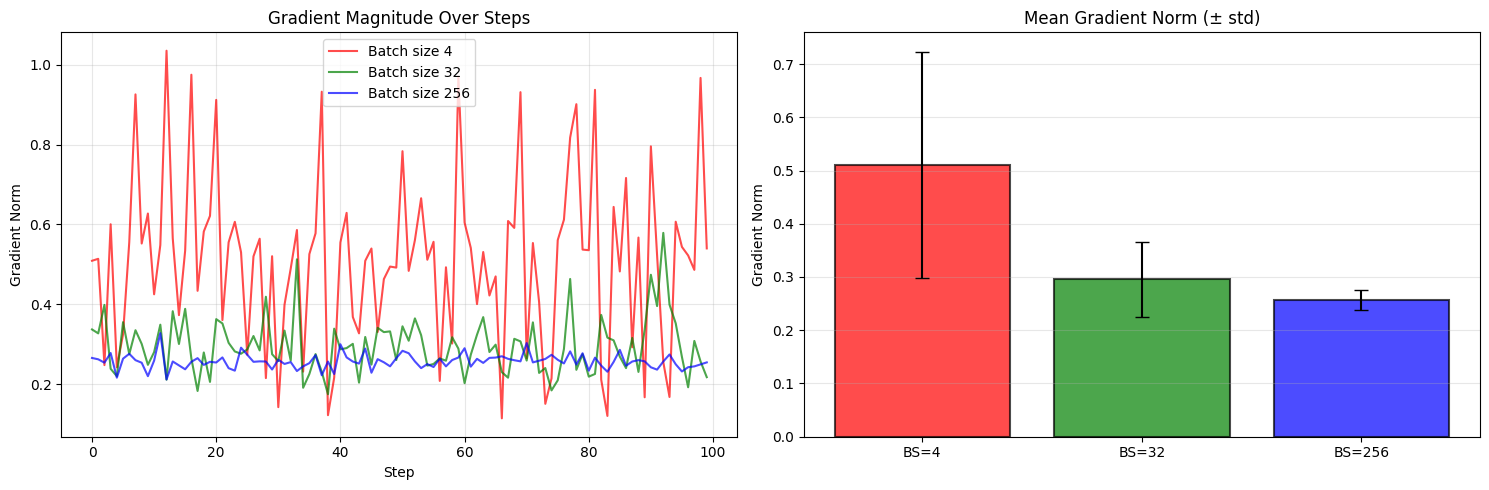


📊 Observations:
  • Small batches → high variance (noisy gradients)
  • Large batches → low variance (stable gradients)
  • Noise can help escape bad minima and improve generalization!


In [14]:
def track_gradient_norms(model, X, y, batch_size=32, num_steps=100):
    """
    Track gradient norms over training steps.
    """
    n = len(X)
    X_tensor = torch.from_numpy(X).to(device)
    y_tensor = torch.from_numpy(y).to(device)
    
    criterion = nn.CrossEntropyLoss()
    gradient_norms = []
    
    for step in range(num_steps):
        # Sample a random batch
        batch_indices = torch.randint(0, n, (batch_size,))
        X_batch = X_tensor[batch_indices]
        y_batch = y_tensor[batch_indices]
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        model.zero_grad()
        loss.backward()
        
        # Compute gradient norm
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        gradient_norms.append(total_norm)
    
    return gradient_norms

# Track gradients for different batch sizes
batch_sizes_test = [4, 32, 256]
gradient_histories = {}

for bs in batch_sizes_test:
    set_seed(42)
    model = SimpleClassifier().to(device)
    gradient_histories[bs] = track_gradient_norms(model, X_train, y_train, batch_size=bs, num_steps=100)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Time series
ax = axes[0]
for bs, color in zip(batch_sizes_test, ['red', 'green', 'blue']):
    ax.plot(gradient_histories[bs], label=f'Batch size {bs}', 
            color=color, linewidth=1.5, alpha=0.7)
ax.set_xlabel('Step')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradient Magnitude Over Steps')
ax.legend()
ax.grid(True, alpha=0.3)

# Statistics
ax = axes[1]
means = [np.mean(gradient_histories[bs]) for bs in batch_sizes_test]
stds = [np.std(gradient_histories[bs]) for bs in batch_sizes_test]

x_pos = np.arange(len(batch_sizes_test))
ax.bar(x_pos, means, yerr=stds, capsize=5, 
       color=['red', 'green', 'blue'], edgecolor='black', linewidth=1.5, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'BS={bs}' for bs in batch_sizes_test])
ax.set_ylabel('Gradient Norm')
ax.set_title('Mean Gradient Norm (± std)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Observations:")
print("  • Small batches → high variance (noisy gradients)")
print("  • Large batches → low variance (stable gradients)")
print("  • Noise can help escape bad minima and improve generalization!")

## Part 15: Summary and Key Takeaways

### Three Flavors of Gradient Descent

| Method | Batch Size | Updates/Epoch | Characteristics |
|--------|-----------|---------------|----------------|
| **Full-Batch** | $n$ (all data) | 1 | Exact gradients, stable but slow |
| **Stochastic** | 1 | $n$ | Many updates, very noisy, low memory |
| **Mini-Batch** | $b$ (typically 16-256) | $\lfloor n/b \rfloor$ | Best balance, standard approach |

### Key Terminology

- **Epoch**: One complete pass through training data
- **Batch**: Subset of data processed together
- **Step/Iteration**: One parameter update
- **Steps per epoch**: $\lfloor n / b \rfloor$ where $n$ = dataset size, $b$ = batch size

### Why Mini-Batching Works

1. **Computational efficiency**: Parallelizes well on GPUs
2. **Memory efficiency**: Fits in GPU memory
3. **Faster convergence**: More updates than full-batch
4. **Better generalization**: Gradient noise acts as regularization
5. **Stable training**: Less noise than pure stochastic

### Practical Guidelines

1. **Start with batch size 32 or 64** for most problems
2. **Increase if you have memory** (128, 256) for faster throughput
3. **Decrease if you overfit** - more noise can help
4. **Scale learning rate** with batch size (linear scaling rule)
5. **Use gradient accumulation** for large effective batches on limited memory

### The Big Picture

Mini-batch gradient descent is the **foundation of modern deep learning**. Understanding:
- Why we use batches (not full dataset)
- How epochs, steps, and batches relate
- The trade-offs between batch sizes
- Why some gradient noise helps

...prepares you to understand optimizers, learning rate schedules, and advanced training techniques!

## Part 16: 🧪 Interactive Experiments

Try these experiments to deepen your understanding:

### Experiment 1: Extreme Batch Sizes
- Try batch size = 2 (nearly stochastic)
- Try batch size = 800 (nearly full-batch)
- How does training change?

### Experiment 2: Learning Rate Scaling
- Double the batch size without changing learning rate
- Does it train worse? Why?
- Now apply the linear scaling rule - does it help?

### Experiment 3: Dataset Size
- Create a tiny dataset (n=100)
- Create a large dataset (n=10,000)
- How does optimal batch size change?

### Experiment 4: Model Complexity
- Make the model bigger (more layers, more hidden units)
- Does batch size affect overfitting differently?

### Experiment 5: Gradient Accumulation
- Compare batch size 128 (direct) vs batch size 128 (via 4×32 accumulation)
- Are they identical? Why or why not?

Experiment: Direct batch 128 vs Accumulated 4×32

Epoch 10/20, Avg Loss: 0.2846
Epoch 20/20, Avg Loss: 0.1877


Epoch 5/20, Loss: 0.3185
Epoch 10/20, Loss: 0.2902
Epoch 15/20, Loss: 0.3018


Epoch 20/20, Loss: 0.1869


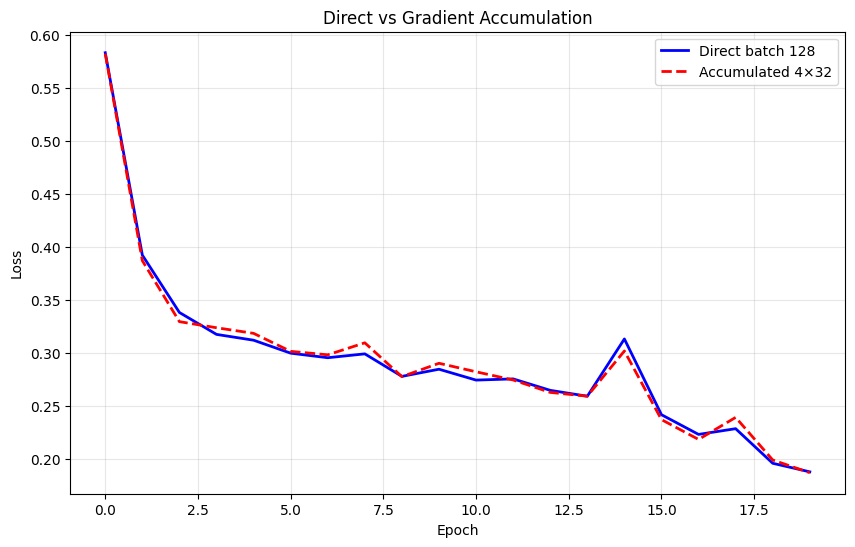


💡 They should be very similar (not identical due to batch ordering)!


In [15]:
# Experiment space - try your own experiments here!

# Example: Compare direct batch vs accumulated batch
print("Experiment: Direct batch 128 vs Accumulated 4×32\n")

# Direct
set_seed(42)
model_direct = SimpleClassifier().to(device)
history_direct = train_mini_batch(model_direct, X_train, y_train, batch_size=128, lr=0.4, num_epochs=20)

# Accumulated
set_seed(42)
model_accum = SimpleClassifier().to(device)
history_accum_exp = train_with_gradient_accumulation(
    model_accum, X_train, y_train, 
    virtual_batch_size=128, micro_batch_size=32, lr=0.4, num_epochs=20
)

# Compare
plt.figure(figsize=(10, 6))
plt.plot(history_direct['loss'], label='Direct batch 128', linewidth=2, color='blue')
plt.plot(history_accum_exp['loss'], label='Accumulated 4×32', linewidth=2, color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Direct vs Gradient Accumulation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 They should be very similar (not identical due to batch ordering)!")

## Part 17: Connection to Optimizers

### Why This Matters for Optimizers

Now that you understand mini-batches, you're ready to learn about **optimizers** (SGD, Adam, etc.)!

Optimizers assume:
- You're using **mini-batch** gradient descent
- Gradients are **noisy** (not exact)
- You need strategies to handle this noise

This is why optimizers like **Adam** and **RMSprop** exist:
- They adapt to the noisy gradient signal
- They maintain running statistics (momentum, variance)
- They adjust learning rates per parameter

### What's Next?

With mini-batch understanding, you can now learn:
1. **Optimizers**: SGD, Momentum, Adam, etc.
2. **Learning rate schedules**: How to adjust LR during training
3. **Batch normalization**: Normalizing activations per batch
4. **Data loaders**: Efficient batch sampling in PyTorch

All of these concepts build on mini-batch gradient descent!

## 🎓 Final Quiz

Test your understanding:

1. **Terminology**: If you have 1,000 examples, batch size 50, and train for 10 epochs, how many parameter updates occur?

2. **Trade-offs**: What are two advantages and two disadvantages of using batch size = 8?

3. **Memory**: If doubling batch size causes OOM errors, what are three solutions?

4. **Learning rates**: You've been using batch size 64 with LR 0.1. You increase to batch size 256. What LR should you use?

5. **Gradient noise**: Why might batch size 32 generalize better than batch size 512?

6. **Real-world**: You're training a transformer on 1M examples with a GPU that fits batch size 16. The paper uses batch size 256. What should you do?

**Answers**:
1. 200 updates (1000/50 = 20 per epoch × 10 epochs)
2. Advantages: More updates, gradient noise helps generalization. Disadvantages: Noisy training, poor GPU utilization
3. Reduce batch size, use gradient accumulation, use a larger GPU/fewer workers
4. 0.4 (scale by 256/64 = 4)
5. More gradient noise → escapes sharp minima → finds flatter, more generalizable solutions
6. Use gradient accumulation: 16 micro-batches per update to simulate batch size 256

## 🎉 Congratulations!

You now have a **deep, intuitive understanding** of mini-batch gradient descent!

### What You've Mastered

✅ The three flavors: full-batch, mini-batch, stochastic  
✅ Terminology: epochs, steps, iterations, batches  
✅ Why gradient noise helps generalization  
✅ Memory and computational trade-offs  
✅ Practical guidelines for choosing batch sizes  
✅ Advanced techniques like gradient accumulation  

### Why This Matters

Mini-batch gradient descent is **not just a detail** - it's the foundation of:
- All modern deep learning training
- Optimizer design (Adam, SGD, etc.)
- Distributed training strategies
- Hardware utilization (GPUs, TPUs)

**You're now ready to dive into optimizers with a solid foundation!** 🚀